# Walk-forward validation: how far ahead can these models actually forecast?

A single train/test split reports one number and hides how a model decays as it
forecasts further into the future. Here I use **expanding-window walk-forward
validation**: re-fit the model at many origins, forecast several steps ahead from
each, and measure the error *per horizon step*. This shows exactly where the
forecast stops being useful.

Two models, two questions:
- **ARIMA on the GOOGL price** — how quickly does point-forecast error (RMSE/MAPE)
  grow, and does the model keep the direction right beyond one step?
- **GARCH on the returns** — how well does the multi-step volatility forecast track
  realised volatility as the horizon grows?

The backtesting logic lives in `timeseries.backtest` so it stays reusable and testable.

In [1]:
import sys

import matplotlib.pyplot as plt

sys.path.insert(0, "src")
from timeseries import (
    auto_arima_select,
    compute_returns,
    fetch_stock,
    metrics_by_horizon,
    plot_degradation,
    prepare_prices,
    walk_forward_arima,
    walk_forward_garch,
)

plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
# Same series the price-forecasting notebook uses, so the results line up.
close = fetch_stock("GOOGL", start="2017-01-01", end="2019-12-31")["Close"]
prices = prepare_prices(close, freq="D")
returns = compute_returns(prices, kind="log").dropna()
print(f"{len(prices)} daily prices, {len(returns)} returns")
prices.tail()

1092 daily prices, 1091 returns


Date
2019-12-26    67.524742
2019-12-27    67.136681
2019-12-28    67.136681
2019-12-29    67.136681
2019-12-30    66.396744
Freq: D, Name: Close, dtype: float64

## 1. ARIMA price forecast — error growth over the horizon

I fix the ARIMA order once with `auto_arima` on the early part of the sample, then
backtest *that* order across the rest. Re-selecting the order at every origin would
be both slow and a form of look-ahead in spirit; fixing it up front is the honest,
standard choice. The window expands by 10 trading days between origins and forecasts
5 days ahead each time.

In [3]:
warmup = int(len(prices) * 0.8)
auto = auto_arima_select(prices.iloc[:warmup], seasonal=False)
order = auto.order
print("selected ARIMA order:", order)

selected ARIMA order: (0, 1, 0)


In [4]:
arima_bt = walk_forward_arima(
    prices, order=order, initial_train_size=warmup, horizon=5, step=10
)
arima_metrics = metrics_by_horizon(arima_bt)
print(f"{arima_bt['origin'].nunique()} forecast origins")
arima_metrics

22 forecast origins


,step,n,mae,rmse,mape,directional_accuracy
0,1,22,0.396327,0.608770,0.681608,0.318182
1,2,22,0.753207,1.374429,1.271726,0.181818
2,3,22,0.954873,1.423606,1.594117,0.000000
3,4,22,1.039396,1.465766,1.727478,0.000000
4,5,22,1.110875,1.491396,1.830747,0.000000


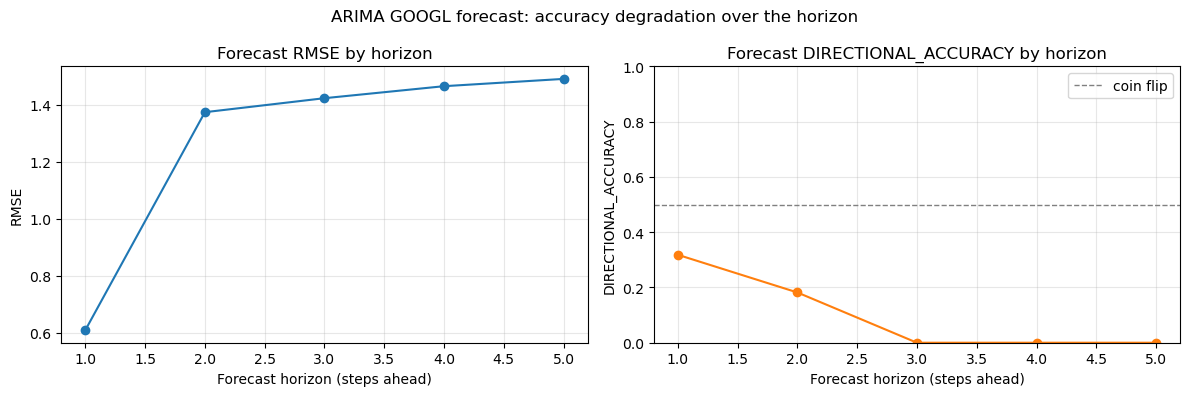

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_degradation(arima_metrics, metric="rmse", ax=axes[0])
plot_degradation(arima_metrics, metric="directional_accuracy", ax=axes[1], color="C1")
axes[1].axhline(0.5, ls="--", color="grey", lw=1, label="coin flip")
axes[1].set_ylim(0, 1)
axes[1].legend()
fig.suptitle("ARIMA GOOGL forecast: accuracy degradation over the horizon")
fig.tight_layout()

RMSE and MAPE climb steadily with the horizon — the random-walk-like price means
uncertainty compounds the further out you forecast. Directional accuracy hovers
around the 0.5 coin-flip line: the level forecast is reasonable a step or two out,
but it carries almost no edge on *which way* the price moves. That is the expected
result for a near-efficient price series, and it is exactly why the volatility
(GARCH) view below is the more productive one for risk.

## 2. GARCH volatility forecast — realised vs forecast volatility

Returns are close to unforecastable in the mean, but their *variance* is
persistent. I backtest a GARCH(1,1) the same way, comparing each step's forecast
volatility against realised volatility (the absolute return) at that step.

In [6]:
garch_bt = walk_forward_garch(
    returns, initial_train_size=warmup, horizon=5, step=10, p=1, q=1
)
garch_metrics = metrics_by_horizon(garch_bt)
garch_metrics[["step", "n", "mae", "rmse"]]

/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/arch/univariate/base.py:310: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001462. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/arch/univariate/base.py:310: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00015. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/home/ankit/miniconda3/envs/DS/lib/python3.1

,step,n,mae,rmse
0,1,22,0.013573,0.020733
1,2,22,0.007499,0.008526
2,3,22,0.008975,0.009771
3,4,22,0.008780,0.010025
4,5,22,0.006537,0.007805


Text(0, 0.5, 'MAE of volatility (|return| proxy)')

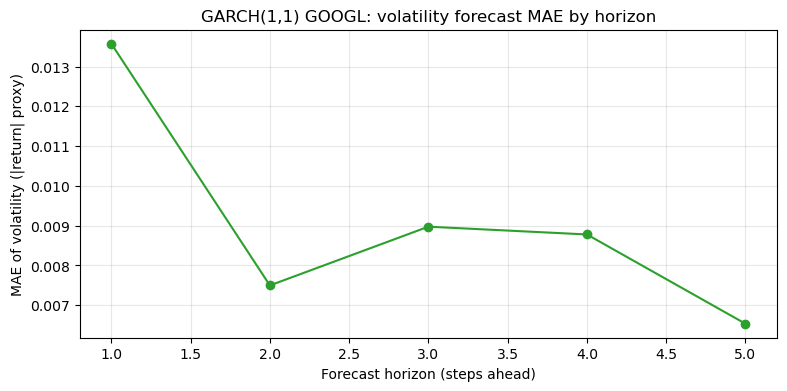

In [7]:
ax = plot_degradation(garch_metrics, metric="mae", color="C2")
ax.set_title("GARCH(1,1) GOOGL: volatility forecast MAE by horizon")
ax.set_ylabel("MAE of volatility (|return| proxy)")

## Takeaways

- **ARIMA on price**: usable one or two steps out, then RMSE/MAPE grow and the
  directional signal washes out to ~0.5. Don't sell it as a multi-day price oracle.
- **GARCH on volatility**: the multi-step volatility forecast stays comparatively
  stable because variance is persistent — mean-reverting toward the long-run level
  rather than compounding the way the price forecast does.
- **Why walk-forward matters**: a single split would have hidden both the horizon
  decay of the price model and the relative robustness of the volatility model.
  Re-fitting at many origins is what makes the comparison fair.